# plotMetric — 强大的自定义数据项绘制脚本

本 notebook 用于：

- 通过给定的.log文件路径(路径可以是数组)解析获取log文件内的所有数据项(定义为函数)
该方法通过匹配解析形如:
Action: [13 21  3] → Rates: [1.40, 2.20]C, Terminal Current: 0.100C
Charging...
Succeed to run the ageing set for 1 cycles the 1th time
Discharging...
Succeed to run RPT for the 1th time
Cycle: 2, SOH(measured): 0.976557
Charge Rates: Stage1=1.40C, Stage2=2.20C | Terminal Current=0.100C
Stage Times: S1=154.08s, S2=843.79s, S3=2244.84s
Rewards: Total=0.924400, r_soh=1.000000, r_time=0.811118, r_soh_val=0.999764, delta_soh=0.148737
Metrics: Avg Temp=20.53°C, Throughput=53.0600Ah, Discharge Cap=4.7509Ah, Terminal V=2.8207V
Aging: LLI=0.123497%, LAM_neg=0.061800%, LAM_pos=0.052733%
文本内从Action:到Aging:的所有metric作为一个cycle数据内容加载到内存中，会忽略中间出现的额外的内容（读取具有鲁棒性：
若只匹配到了Action:但是没有匹配到Aging:，该cycle内容视为不完整，不进行记录
若数据项行之间存在:
Electrolyte is being squeezed out, check plated lithium (active and dead)
[ERROR][rank 0][/home/conda/feedstock_root/build_artifacts/sundials-split_1763196359154/work/sundials/src/idas/idas_ic.c:1413][IDAICFailFlag] The linesearch algorithm failed: step too small or too many backtracks.
等等除数据外的额外内容，匹配过程中会直接忽略，
因此形如Action--(任意任何额外内容)--Aging-(任意任何额外内容)-Action--Aging会被成功解析为两个完整的cycle数据
形如Action--(假如求解器找不到解)--Action--Aging只有第二个循环会被成功解析
会将整个log文件内的所有该pattern数据全部解析到df,
数据按照原读取顺序排序 不做额外排序
- 给出了一个强大的数据绘制函数示例plot_metric(sources=[('logPathA.log','NameA'),('logPathB.log','NameB'),...],Y=['MetricA','MetricB',...],X=['MetricA_x','MetricB_x',...])
该函数会尝试将从两个(任意个)log文件中通过功能1的log读取功能获得对应的df，然后试图将两个df中的MetricA作为y,MetricB作为x对应的曲线以名字'NameA',NameB'绘制到交互式图(并不会输出图片文件，但是有输出到图片的功能)
Metric的名字为事先给出的string列表 表示能从log文件获得的数据项 仅用于数据识别，例如'lli'可以是获取到的LLI:(数据%),'throughput_ah'可以是Throughput=(数据Ah)
特别的 当x数据metric为throughput_ah或cycle的时候 该函数会对该x,y做额外内容：
该函数会将原数据以递增的形式split成多个数据(例如cycle:1-2-3-4-1-2-3-1-2,会被split成三个run数据,分别是run1:cycle:1-2-3-4;run2:cycle:1-2-3:run3:cycle:1-2,throughpput_ah同理) 对应的曲线的名字将会是NameA_run1,NameB_run2,......
- 使用 science 风格 `plt.style.use(["science","no-latex"])`。

新添加功能：强大的字符串数学公式解析，X,Y接受的不仅仅是字符串键名'S1''S2''S3'，而是包含了公式的字符串'S1+S2+S3''LLI+LAM_pos+LLI*LAM_pos' 此时该参数会按照公式计算完毕的df进行plot
此时 因为复杂的逻辑依赖 曲线的名字一定由curveNames给出的名字命名 如果curveNames没有对应的名字直接报错
如果该功能与现有的函数实现冲突 请你另行声明新函数
细节修改:
- 如果x坐标要绘制的参数是连续的，例如X=['Throughput', 'Throughput', 'Throughput', 'Cycle'] 是否只在throughput的最后一个x_label设置名字即可 而不需要每个axis都设置
- 物理量没有单位？
新添加的功能必须实现 细节1可以不实现（如果破坏了整个绘制逻辑） 细节2必须实现

In [11]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 尝试应用 Science 风格，如未安装 scienceplots 则回退至默认样式
try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except ImportError:
    pass

def parse_log_to_df(filepath):
    """
    鲁棒地从日志文件中提取 Cycle 运行数据并返回 Pandas DataFrame。
    利用状态机机制自动过滤噪声。同时在特征名中保留捕获到的单位信息。
    """
    data = []
    in_cycle = False
    current_cycle_data = {}
    
    # 广义匹配 "Key=Value" 或 "Key: Value"，同时捕获可选的后缀单位
    # group(1): 键名, group(2): 数值, group(3): 单位(如 °C, Ah, %, s, V)
    pattern = re.compile(r'([A-Za-z0-9_\s\(\)]+?)\s*[=:]\s*([+-]?\d+\.?\d*(?:[eE][+-]?\d+)?)\s*([a-zA-Z%°]+)?')

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if 'Action:' in line:
                in_cycle = True
                current_cycle_data = {}
            
            if in_cycle:
                for match in pattern.finditer(line):
                    key = match.group(1).strip()
                    val = float(match.group(2))
                    unit = match.group(3)
                    
                    # 细节2：在键名保留物理量单位
                    if unit and unit.strip() in ['Ah', 'C', 's', '%', 'V', '°C']:
                        final_key = f"{key} [{unit.strip()}]"
                    else:
                        final_key = key
                        
                    current_cycle_data[final_key] = val
                    
            if 'Aging:' in line and in_cycle:
                data.append(current_cycle_data)
                in_cycle = False
                
    return pd.DataFrame(data)

def _eval_math_string(df, expr_str):
    """
    辅助函数：基于 DataFrame 安全地执行带数学公式的字符串，并返回 Series。
    解决 DataFrame 列名带空格、括号等无法直接 pd.eval() 的痛点。
    """
    # 构建基础特征命名（不含我们附加的单位后缀）到真实 DataFrame 列名的映射
    base_to_real = {c.split(' [')[0].strip(): c for c in df.columns}
    
    # 如果字符串完全等于某剔除后缀后的列名，直接返回以节省算力，同时保留原先的 name（包含单位）
    exact_match = next((real for base, real in base_to_real.items() if expr_str.lower() == base.lower()), None)
    if exact_match:
        return df[exact_match]
        
    # 构建一个临时字典，将带有特殊字符的列名映射为合法的 Python 变量名
    local_vars = {}
    modified_expr = expr_str
    
    # 按长度从大到小替换，防止子串替换冲突 (如 LAM_pos 被 LAM 替换)
    keys_sorted = sorted(df.columns, key=len, reverse=True)
    for i, col in enumerate(keys_sorted):
        # 取出列名本体（去除我们添加的单位后缀等）
        base_name = col.split(' [')[0].strip()
        safe_var_name = f"VAR_{i}"
        
        # 如果表达式中含有该列的特征名（忽略大小写，利用正则替换保证词边界）
        if base_name in modified_expr or base_name.lower() in modified_expr.lower():
            # 大小写不敏感地替换原名字为 VAR_x
            pattern = re.compile(re.escape(base_name), re.IGNORECASE)
            modified_expr = pattern.sub(safe_var_name, modified_expr)
            local_vars[safe_var_name] = df[col]
            
    try:
        # 使用 numpy 与临时变量评估数学公式
        return eval(modified_expr, {"__builtins__": None, 'np': np}, local_vars)
    except Exception as e:
        print(f"[Error] 解析数学表达式 '{expr_str}' 失败，请检查语法及所用列名！详情: {e}")
        return None

def split_runs_by_monotonicity(df, key_series):
    """
    通过检测单调性将 DataFrame 拆分为多个 Run 序列。
    接受的不再是关键字符串，而是具体的 Series 数据用于判定。
    """
    if key_series is None or key_series.empty:
        return [df]
    
    diffs = key_series.diff()
    split_indices = key_series.index[diffs <= 0].tolist()
    
    runs = []
    start_idx = 0
    for idx_val in split_indices:
        iloc_pos = df.index.get_loc(idx_val)
        if iloc_pos > start_idx:
            runs.append(df.iloc[start_idx:iloc_pos])
        start_idx = iloc_pos
    runs.append(df.iloc[start_idx:])
    
    return [r for r in runs if not r.empty]

def plot_math_metric_curve(sources, Y, X, smoothing_window=None, runsPlotting=None, curveNames=None):
    """
    高阶可视化接口，支持基于数学公式的 X, Y 轴特征传入，且图例绑定强校验。
    Y 接受 list，元素可以是 'MetricExpr' 字符串，或者是 ('MetricExpr', 'CustomAxisLabel') 元组以自定义y轴标签。
    """
    # 如果调用基于公式的复杂版本，必须提供合法对齐的 curveNames 防止图例混乱
    if curveNames is None:
        raise ValueError("[Error] 使用包含数学公式绘图功能时，必须显式提供 curveNames 防止图例命名失效！")
        
    # 预处理 Y 参数，分理出表达式和自定义 Y 轴标签
    y_exprs = []
    y_custom_labels = []
    for y_item in Y:
        if isinstance(y_item, (tuple, list)) and len(y_item) == 2:
            y_exprs.append(y_item[0])
            y_custom_labels.append(y_item[1])
        else:
            expr = y_item[0] if isinstance(y_item, (tuple, list)) else y_item
            y_exprs.append(expr)
            y_custom_labels.append(None)
            
    if len(X) < len(y_exprs):
        X = X + [X[-1]] * (len(y_exprs) - len(X))
        
    num_plots = len(y_exprs)
    fig, axes = plt.subplots(num_plots, 1, figsize=(8, 4 * num_plots), dpi=150)
    if num_plots == 1:
        axes = [axes]
        
    split_triggers = ['throughput', 'cycle']
    
    # 建立外层容器，用来捕获带单位的最终轴标签名
    final_Y_labels = list(y_exprs)
    final_X_labels = list(X)
    
    for source_idx, (log_path, label_name) in enumerate(sources):
        if not os.path.exists(log_path):
            print(f"[Warning] 路径未找到: {log_path}")
            continue
            
        df = parse_log_to_df(log_path)
        if df.empty: continue
            
        target_runs = runsPlotting[source_idx] if runsPlotting and source_idx < len(runsPlotting) else []
        target_names = curveNames[source_idx] if source_idx < len(curveNames) else ()
        
        # 兼容性修复：如果用户直接传入字符串而不是元组，那么将其安全包裹为元组以防止被当做字符迭代
        if isinstance(target_names, str):
            target_names = (target_names,)
        
        for plot_idx, (ax, y_expr, x_expr) in enumerate(zip(axes, y_exprs, X)):
            
            # 使用内置引擎计算可能具有数学表达式的 X/Y 数据 Series
            x_series = _eval_math_string(df, x_expr)
            y_series = _eval_math_string(df, y_expr)
            
            if x_series is None or y_series is None: continue
            
            # 捕获带有物理单位的序列名，如果 eval 是精确匹配返回，则含有 `.name` (如 'Throughput [Ah]')
            if hasattr(y_series, 'name') and y_series.name:
                final_Y_labels[plot_idx] = y_series.name
            if hasattr(x_series, 'name') and x_series.name:
                final_X_labels[plot_idx] = x_series.name
            
            window = 1
            if smoothing_window:
                if isinstance(smoothing_window, int): window = smoothing_window
                elif isinstance(smoothing_window, list) and plot_idx < len(smoothing_window): window = smoothing_window[plot_idx]
            
            trigger_split = any(t in x_expr.lower() for t in split_triggers)
            
            if trigger_split:
                runs = split_runs_by_monotonicity(df, x_series)
                valid_draw_idx = 0
                for i, run_df in enumerate(runs):
                    run_index = i + 1
                    if target_runs and run_index not in target_runs: continue
                        
                    if len(target_names) <= valid_draw_idx or not target_names[valid_draw_idx]:
                        raise ValueError(f"[Error] curveNames 未能为 plot 索引提供所需的命名元组映射：缺少有效的名字。")
                    
                    run_label = target_names[valid_draw_idx]
                            
                    # 同步切取被裁剪的 df 的特定片断
                    run_y_data = y_series.loc[run_df.index]
                    run_x_data = x_series.loc[run_df.index]
                    
                    if window > 1: run_y_data = run_y_data.rolling(window=window, min_periods=1).mean()
                    ax.plot(run_x_data, run_y_data, marker='o', markersize=3, label=run_label)
                    valid_draw_idx += 1
            else:
                if len(target_names) <= 0 or not target_names[0]:
                    raise ValueError(f"[Error] curveNames 不能为空，必须为该图例曲线提供自定义名字！")
                run_label = target_names[0]
                
                if window > 1: y_series = y_series.rolling(window=window, min_periods=1).mean()
                ax.plot(x_series, y_series, marker='o', markersize=3, label=run_label)
                
    for plot_idx, (ax, y_col, x_col, custom_y) in enumerate(zip(axes, final_Y_labels, final_X_labels, y_custom_labels)):
        # 细节1：如果前面的图 X 轴是联动的相同变量，只在最底下的子图设置 xlabel 以保持界面整洁
        if plot_idx < len(final_X_labels) - 1 and final_X_labels[plot_idx] == final_X_labels[plot_idx+1]:
            ax.set_xlabel('')
        else:
            ax.set_xlabel(x_col, fontweight='bold')
            
        y_label = custom_y if custom_y is not None else y_col
        ax.set_ylabel(y_label, fontweight='bold')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout()
    plt.show()

In [12]:
# === 可用数据项 (Metrics) 参考字典与列表 ===
# 为方便在绘图时随时调用，在此列出通过上述正则引擎自动解析出的合法变量名。
# 您可以直接在 plot_metric 的 X 或 Y 参数中填入以下字符串（或其子串，如 'throughput'）

AVAILABLE_METRICS = [
    # 1. 周期与全局状态
    "Cycle", 
    "SOH(measured)",
    
    # 2. 充电策略参数 (Current / C-rate)
    "Stage1", 
    "Stage2", 
    "Terminal Current", 
    
    # 3. 各阶段耗时 (Seconds)
    "S1", 
    "S2", 
    "S3", 
    
    # 4. 强化学习奖励值 (Rewards)
    "Total", 
    "r_soh", 
    "r_time", 
    "r_soh_val", 
    "delta_soh",
    
    # 5. 电池外特性与状态指标
    "Avg Temp", 
    "Throughput", 
    "Discharge Cap", 
    "Terminal V",
    
    # 6. 电池内部老化机理 (Aging)
    "LLI", 
    "LAM_neg", 
    "LAM_pos"
]

# 打印所有项以便于检查
print("可直接用于绘图的数据项名称如下：")
for i, metric in enumerate(AVAILABLE_METRICS, 1):
    print(f"{i:02d}. {metric}")

可直接用于绘图的数据项名称如下：
01. Cycle
02. SOH(measured)
03. Stage1
04. Stage2
05. Terminal Current
06. S1
07. S2
08. S3
09. Total
10. r_soh
11. r_time
12. r_soh_val
13. delta_soh
14. Avg Temp
15. Throughput
16. Discharge Cap
17. Terminal V
18. LLI
19. LAM_neg
20. LAM_pos


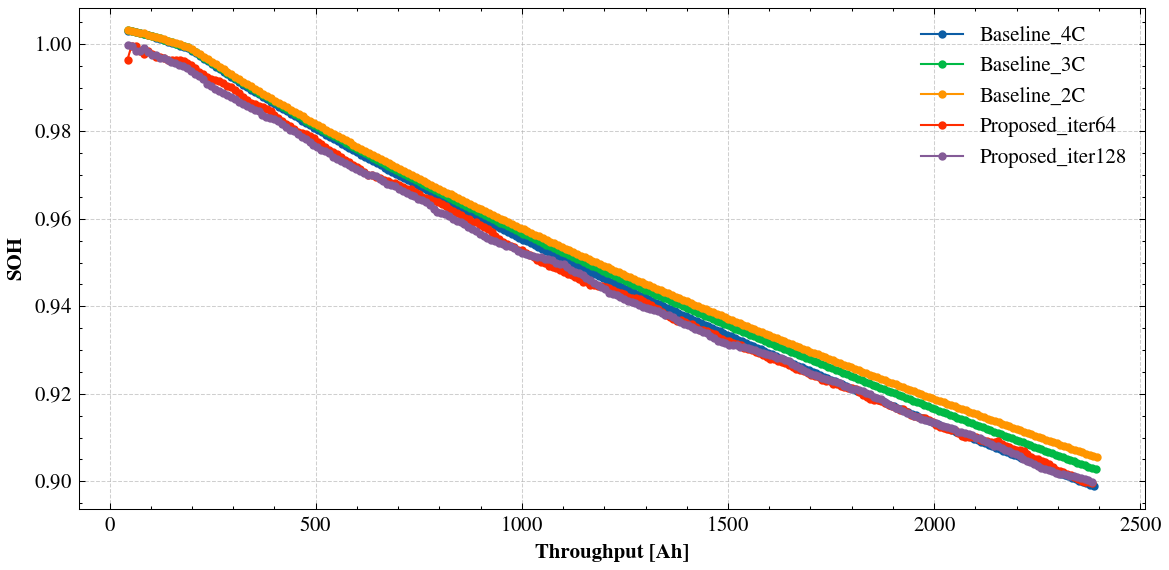

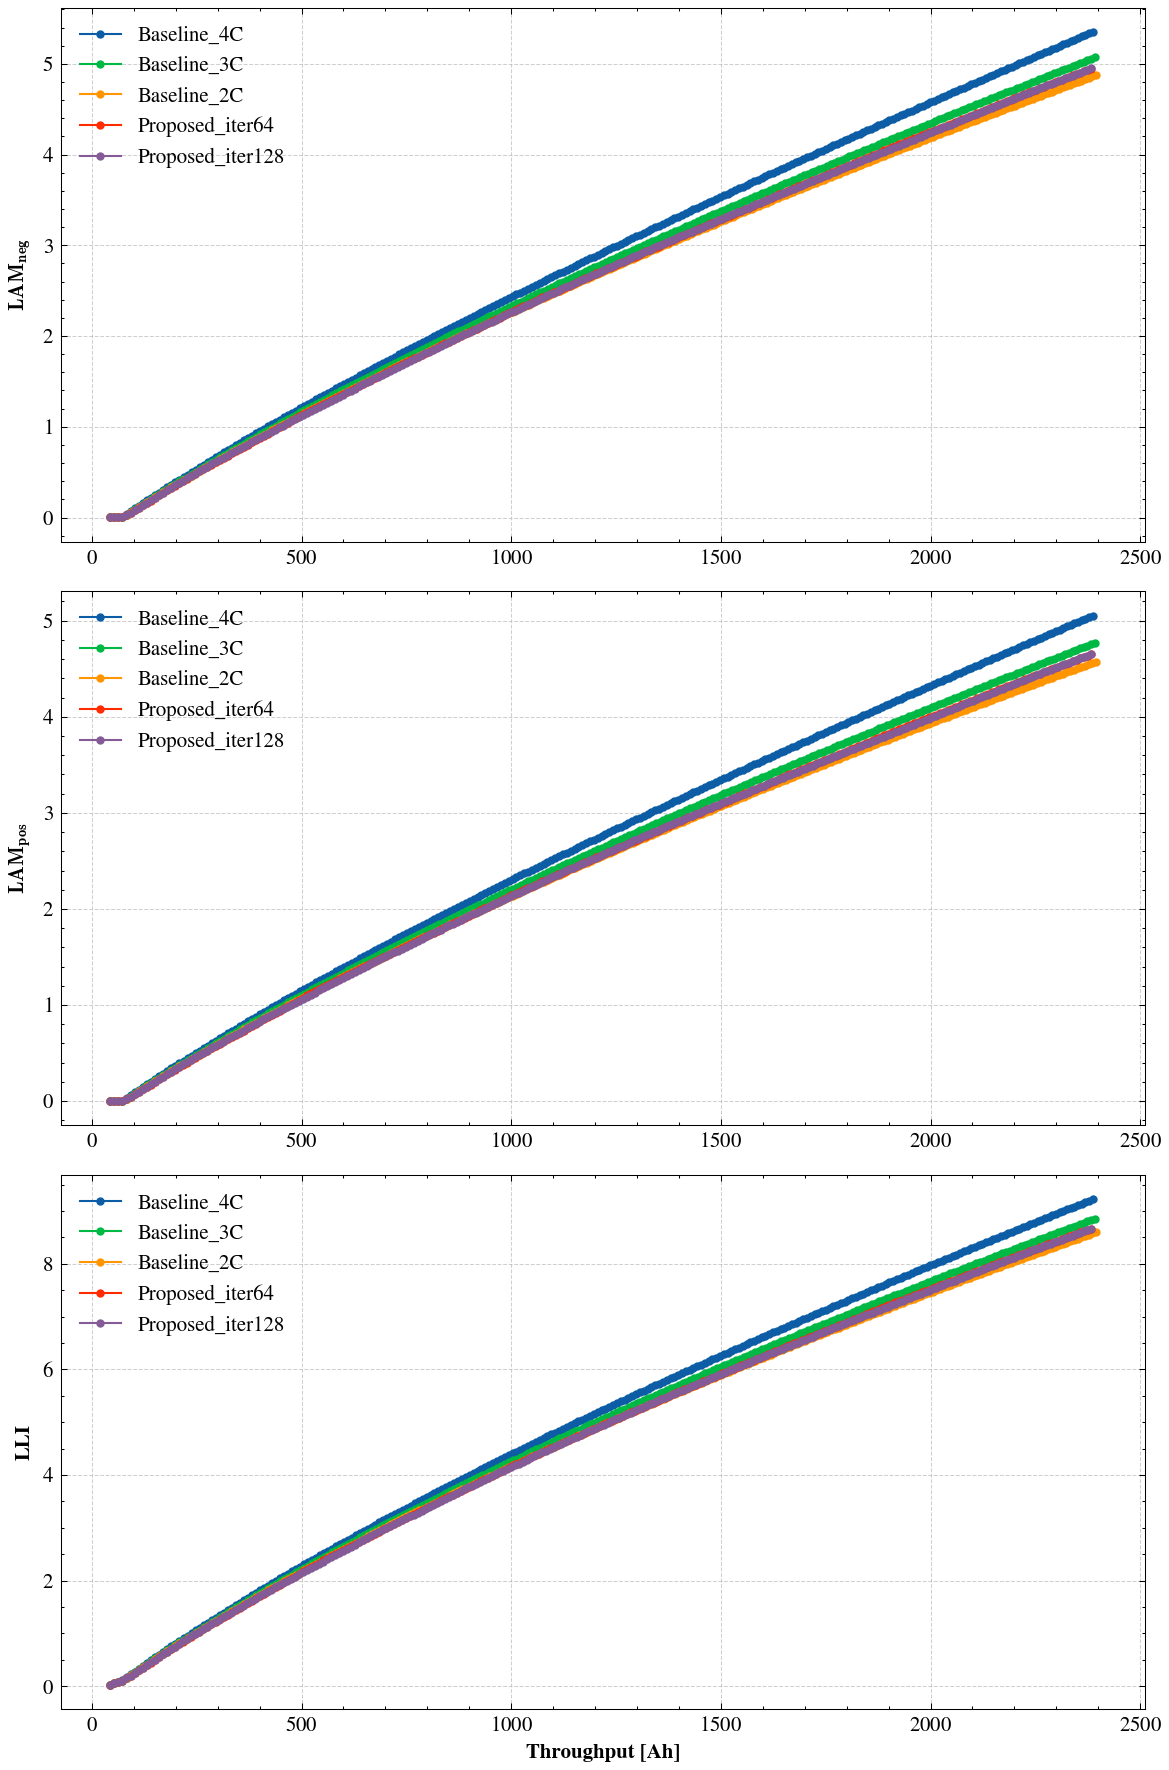

In [13]:
# --- 示例调用（您可以修改或注释掉） ---
temperature = 40

baseline_path = f"baseline_data/T{temperature}"


sources_example = [
    (f'{baseline_path}/action_4C_4C_0p01C/env_0.log', f'Baseline_T{temperature}_4c'),
    (f'{baseline_path}/action_3C_3C_0p01C/env_0.log', f'Baseline_T{temperature}_3c'), 
    (f'{baseline_path}/action_2C_2C_0p01C/env_0.log', f'Baseline_T{temperature}_2c'),  # 添加第二条 Baseline 2C 线
    ('overhauled_train_iter2/T40/env_6.log', 'Proposed')]
plot_math_metric_curve(
    sources_example, 
    Y=[('SOH(measured)', 'SOH'), ],
    X=['Throughput',], 
    smoothing_window=[16,], 
    runsPlotting=[[1], [1], [1], [2,3]],  # Baseline 全部 run，Proposed 仅 run1
    curveNames=[(f'Baseline_4C'), (f'Baseline_3C'), (f'Baseline_2C'), ('Proposed_iter64', 'Proposed_iter128')]  # 仅覆盖 Proposed 的两条线名
    )

plot_math_metric_curve(
    sources_example, 
    Y=[
        ('LAM_neg', r'$\mathbf{LAM_{neg}}$'), 
        ('LAM_pos', r'$\mathbf{LAM_{pos}}$'), 
        ('LLI', 'LLI')], 
    X=['Throughput', 'Throughput', 'Throughput'], 
    smoothing_window=[1, 1, 1,], 
    runsPlotting=[[1], [1], [1], [2,3]],  # Baseline 全部 run，Proposed 仅 run1
    curveNames=[(f'Baseline_4C'), (f'Baseline_3C'), (f'Baseline_2C'), ('Proposed_iter64', 'Proposed_iter128')]  # 仅覆盖 Proposed 的两条线名
    )

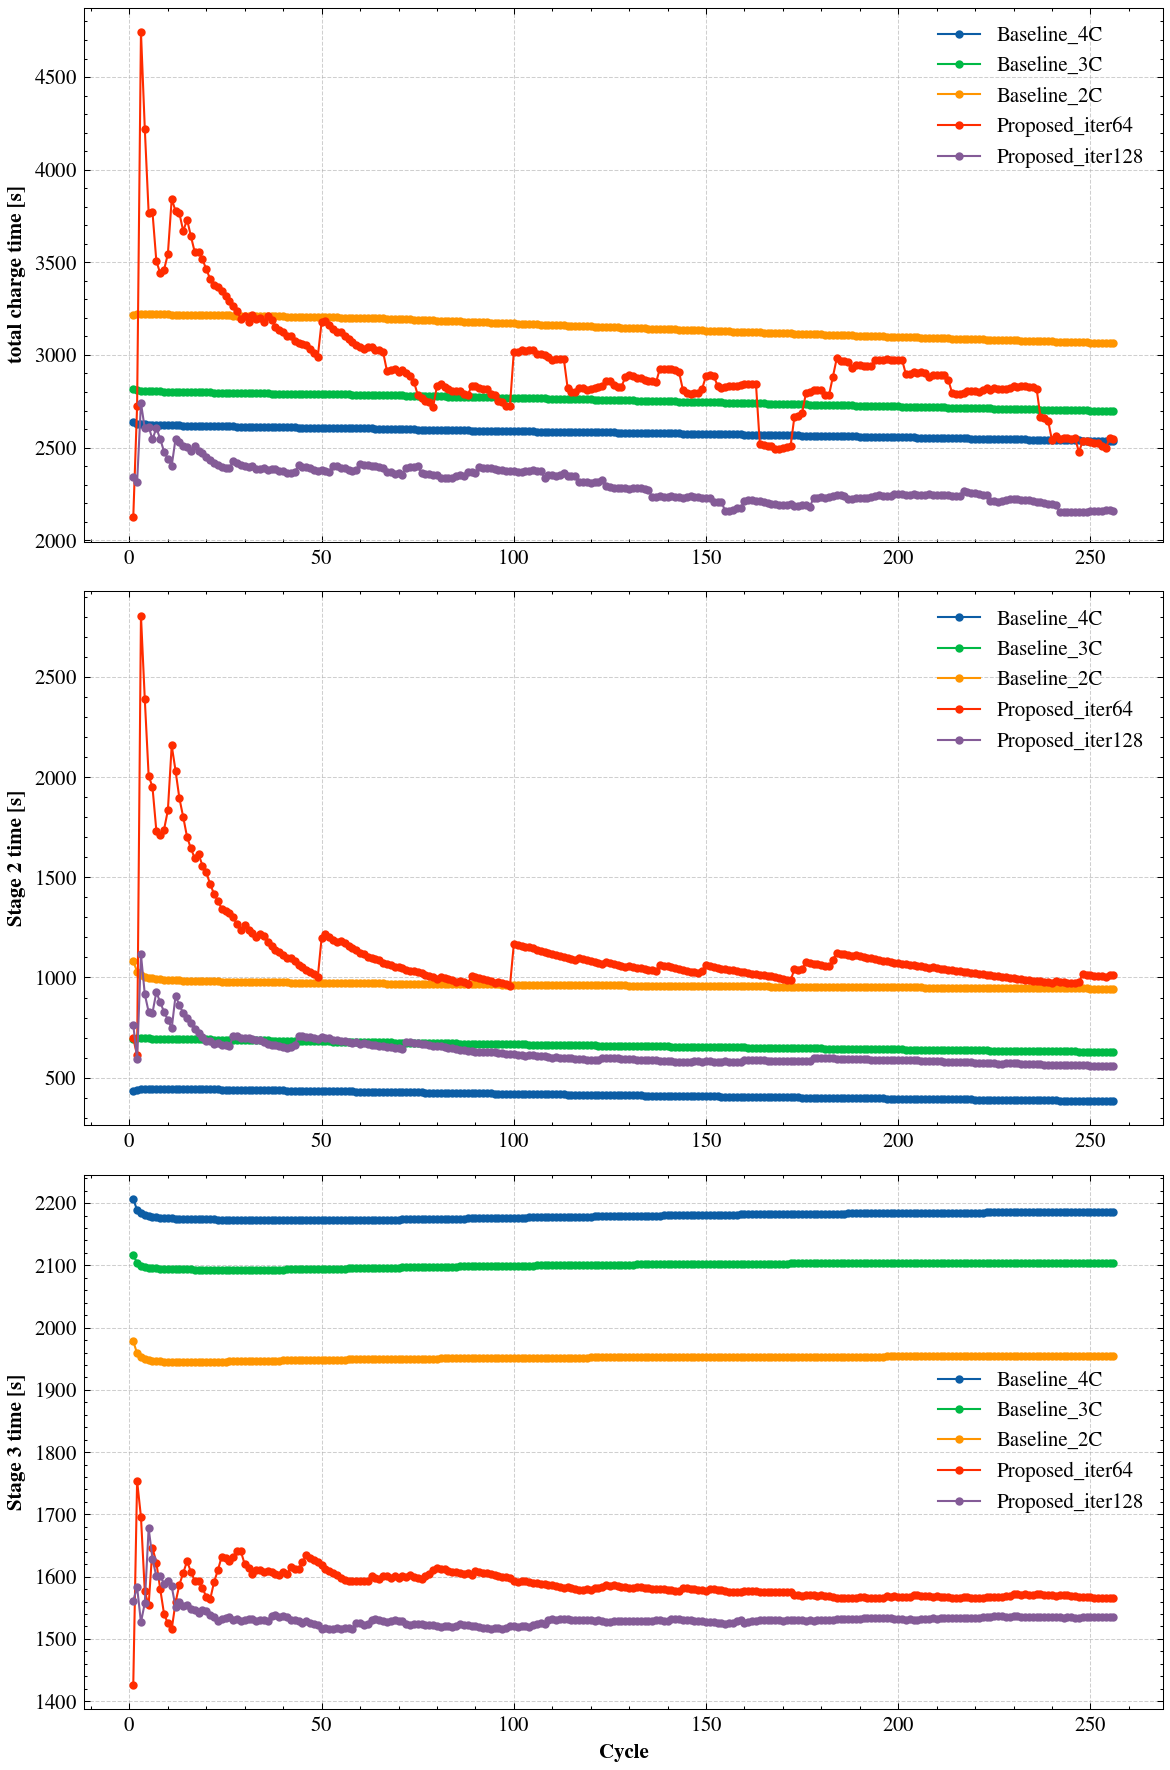

In [14]:
# --- 示例调用（您可以修改或注释掉） ---
temperature = 40

baseline_path = f"baseline_data/T{temperature}"


sources_example = [
    (f'{baseline_path}/action_4C_4C_0p01C/env_0.log', f'Baseline_T{temperature}_4c'),
    (f'{baseline_path}/action_3C_3C_0p01C/env_0.log', f'Baseline_T{temperature}_3c'),
    (f'{baseline_path}/action_2C_2C_0p01C/env_0.log', f'Baseline_T{temperature}_2c'), 
    ('overhauled_train_iter2/T40/env_6.log', 'Proposed')]
plot_math_metric_curve(
    sources_example, 
    Y=[
        ('S1+S2+S3', 'total charge time [s]'),
        ('S2', 'Stage 2 time [s]'),
        ('S3', 'Stage 3 time [s]')
        ], 
    X=['Cycle',], 
    smoothing_window=[64, 2048, 2048], 
    runsPlotting=[[1], [1], [1], [2,3]],  # Baseline 全部 run，Proposed 仅 run1
    curveNames=[(f'Baseline_4C'), (f'Baseline_3C'), (f'Baseline_2C'), ('Proposed_iter64', 'Proposed_iter128')]  # 仅覆盖 Proposed 的两条线名
    )

In [15]:
import ipywidgets as widgets
from IPython.display import display, clear_output

temperature = 25
baseline_path = f"baseline_data/T{temperature}"

def interactive_plot(env_id):
    sources_example = [
        (f'{baseline_path}/action_4C_4C_0p01C/env_0.log', f'Baseline_T{temperature}_4c'),
        (f'{baseline_path}/action_3C_3C_0p01C/env_0.log', f'Baseline_T{temperature}_3c'),
        (f'{baseline_path}/action_2C_2C_0p01C/env_0.log', f'Baseline_T{temperature}_2c'), 
        (f'overhauled_train_iter2/T{temperature}/env_{env_id}.log', 'Proposed')
    ]
    
    # 调用绘图接口
    plot_math_metric_curve(
        sources_example, 
        Y=[
            ('SOH(measured)','SOH'),
            ('LAM_neg',r'$LAM_{neg}$'),
            ('LAM_pos',r'$LAM_{pos}$'),
            ('LLI','LLI'),
            ('S1+S2+S3','S1+S2+S3')
        ], 
        X=['Throughput', 'Throughput', 'Throughput', 'Throughput', 'Cycle'], 
        smoothing_window=[16, 1, 1, 1, 64], 
        runsPlotting=[[1], [1], [1], [2,3]],  # Baseline 全部 run，Proposed 仅 run1
        curveNames=[
            (f'Baseline_T{temperature}_4c'), 
            (f'Baseline_T{temperature}_3c'),
            (f'Baseline_T{temperature}_2c'),
            ('Proposed_iter64', 'Proposed_iter128')]  # 仅覆盖 Proposed 的两条线名
    )

# 创建交互式下拉菜单（假设当前环境有 0-10 等多个 id，您可根据实际 log 文件列表调整 options）
env_dropdown = widgets.Dropdown(
    options=[i for i in range(64)],  # 这里默认提供 0-19，如有更具体文件可使用 os.listdir 动态获取
    value=0,
    description='Env ID:',
    disabled=False,
)

# 绑定交互事件
widgets.interact(interactive_plot, env_id=env_dropdown);

interactive(children=(Dropdown(description='Env ID:', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1…